# v10: Confusion Matrix + t-SNE Misclassification Analysis

**1024-dim embeddings版** — PanDerm CLS token (1024次元) でt-SNEを実行。
v8と同一backboneだがFitzpatrick17k（臨床写真）テストセットで評価。

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from pathlib import Path
import seaborn as sns

# ── Config ─────────────────────────────────────────────
NPZ_PATH = Path('../results/models/v10_test_predictions.npz')
EMB_PATH = Path('../results/embeddings/v10_test_embeddings.npz')
PH_PATH  = Path('../results/v10/posthoc_thresholds_v10.json')
OUT_DIR  = Path('../results/tsne')
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'benign dermal', 'benign epidermal', 'benign melanocyte',
    'malignant dermal', 'malignant epidermal', 'malignant melanoma',
]
CLASS_SHORT = {
    'benign dermal':       'B-Derm',
    'benign epidermal':    'B-Epi',
    'benign melanocyte':   'B-Mel',
    'malignant dermal':    'M-Derm',
    'malignant epidermal': 'M-Epi',
    'malignant melanoma':  'M-Mela',
}
CLASS_LABELS = {
    'benign dermal':       'B-Derm\n(Benign Dermal)',
    'benign epidermal':    'B-Epi\n(Benign Epidermal)',
    'benign melanocyte':   'B-Mel\n(Benign Melanocyte)',
    'malignant dermal':    'M-Derm\n(Malig. Dermal)',
    'malignant epidermal': 'M-Epi\n(Malig. Epidermal)',
    'malignant melanoma':  'M-Mela\n(Melanoma)',
}
MALIGNANT = {'malignant dermal', 'malignant epidermal', 'malignant melanoma'}
MALIGNANT_INDICES = [i for i, c in enumerate(CLASS_NAMES) if c in MALIGNANT]
BENIGN_INDICES    = [i for i, c in enumerate(CLASS_NAMES) if c not in MALIGNANT]
MEL_IDX = CLASS_NAMES.index('malignant melanoma')

CLASS_COLORS = {
    'benign dermal':       '#3b82f6',
    'benign epidermal':    '#06b6d4',
    'benign melanocyte':   '#2563eb',
    'malignant dermal':    '#e11d48',
    'malignant epidermal': '#dc2626',
    'malignant melanoma':  '#7f1d1d',
}
Path('../results/embeddings').mkdir(parents=True, exist_ok=True)


## 0. Feature Extraction (1024-dim embeddings)

PanDerm ViT-Large の CLS token (1024次元) を抽出。
v8と同一のbackboneだが、入力がFitzpatrick17k（臨床写真）のテストセット。

In [2]:
# ── 1024-dim embedding extraction (PanDerm + Fitz17k) ──
# Data split は v10.ipynb と完全一致させる必要がある
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
import os, sys, importlib.util
import warnings
warnings.filterwarnings("ignore", message="Overwriting.*in registry")
warnings.filterwarnings("ignore", category=FutureWarning, module="timm")
warnings.filterwarnings("ignore", message="torch.meshgrid")

if EMB_PATH.exists():
    print(f'Embeddings already exist: {EMB_PATH} — skipping extraction')
else:
    print('Extracting 1024-dim embeddings from PanDerm ViT-Large (Fitz17k)...')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Fitz17k data prep (v10.ipynb と完全同一) ──────────
    FITZ_CSV = '../data/fitzpatrick17k/fitzpatrick17k.csv'
    IMG_DIR = Path('../data/fitzpatrick17k/images')

    df = pd.read_csv(FITZ_CSV)

    # QC filter (v10.ipynb Cell 5)
    if 'qc' in df.columns:
        before = len(df)
        df = df[~df['qc'].isin(['3 Wrongly labelled', '4 Other'])].reset_index(drop=True)
        print(f'  After QC filter: {len(df)} (removed {before - len(df)})')

    # FST filter (v10.ipynb: fitzpatrick_scale != -1)
    df = df[df['fitzpatrick_scale'] != -1].reset_index(drop=True)

    # Image existence filter
    df['img_path'] = df['md5hash'].apply(lambda x: str(IMG_DIR / f'{x}.jpg'))
    df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)

    # Tumor-only filter (exclude inflammatory, genodermatoses, malignant cutaneous lymphoma)
    EXCLUDE_CLASSES = ['inflammatory', 'genodermatoses', 'malignant cutaneous lymphoma']
    df = df[~df['nine_partition_label'].isin(EXCLUDE_CLASSES)].reset_index(drop=True)

    # Class mapping (sorted unique → idx, v10.ipynb と同一)
    CLASS_NAMES_9 = sorted(df['nine_partition_label'].unique().tolist())
    class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES_9)}
    df['class_idx'] = df['nine_partition_label'].map(class_to_idx)

    # Dedup (v10.ipynb の23ペア)
    duplicates = {
        '5f567374f688120109c2bab349ff21cf': '22f1d783dd6821defafcc915a8146c41',
        '6de74d3051ceafe10cf3f3e8c342bad8': 'be030bdb35c3c8cbf9145dfcebc0c0d2',
        '19a1b36184861141cd3b1cd43e74b5b6': 'dbee4a80595e78f281e1a0938f9857be',
        'a7ef35e99387ff1227baced72467dc1f': '33068b46548282d53e5fee2f15792728',
        '6cd57e29acb9071a6c5e5aa23aeaf0ee': '11e1eeb117aafe575e95f9c2ee9de3f3',
        'adb5b7253c21d274f9b1a793b01b84d2': '3554761709cc4906ab9db13e5e46aa25',
        'ea7c258aade6d510197d02b8d5012ba5': 'e6b375b8b1b7e27706623977dace3721',
        '38682083d6f7539a88c17d57559dcbd6': '2b16c87c36fa56721ab867e53560ec9b',
        '1cc5a0ffcaf2f370cd65f10eeeb7fddd': '9b82bbff48d88f3bea9d30cfd96606dc',
        '8633a0075168ec7587c636bde73fcb21': '09d46db9589ff45436cda87c4abc946b',
        '771fff032a6c7854eb8509f5849e929e': 'bf77bafaa320f244f2331ca466b96f50',
        '95727ec19e5e87adf63dc241cb5e4af8': '9829c11b6a2ea0a47031a865d761a670',
        'a027f129d0ed0d55f8c0c455d9de0035': 'ba8e7927c71912e42cde00184b691376',
        'fd5dd82519cfa82bd6f23d9f83b421aa': '34b5d983d901815b931e28ee357ddf74',
        'bb7eaaccb79a069d59db68a3cae983cb': 'd519b2976ab7e3da9c334540018cad79',
        'f7a234c59d01011f64c9633409a30086': 'a36d079aeee1bd073859a3af6041c4f4',
        'a874b1654043ff9c19375a4b04be79a3': '8e4fcec9d635f8e9c152a23aad631eec',
        'fcb25afb92552dceba953b8254544a19': '0455b31fb640b89ee7375711168f318b',
        '5041af68a1e046acff0fc93da11de68f': '0e2a24d28767bea1a4a37d1c6a4d4f31',
        'bf0403884214daf1e41bdb522df8c8a1': '1efcd7e523f9cdf487d1be5ec88e546a',
        '59c60187f6e65c32cbbadbdfc8b8df1d': '8e8674abd53e4d087da3798f478edb8c',
        '81ccde6038a8c7bf6860774ebaf4bad8': '5eebe4328896867cce5c841d7d15d765',
        'e2e1cf7d3e85b5bcbb00223931f84487': 'd56d52145880b5280cc2d18c9b4a89f7',
    }
    remove_hashes = set(duplicates.values())
    df = df[~df['md5hash'].isin(remove_hashes)].reset_index(drop=True)

    # Split (v10.ipynb: test_size=0.15, random_state=42)
    df_trainval, df_test = train_test_split(
        df, test_size=0.15, random_state=42, stratify=df['class_idx']
    )
    df_test = df_test.reset_index(drop=True)
    print(f'  Test set: {len(df_test)} images (expect 475)')

    # ── PanDerm backbone ──
    spec = importlib.util.spec_from_file_location(
        "modeling_finetune",
        os.path.expanduser("~/PanDerm/classification/models/modeling_finetune.py")
    )
    mf = importlib.util.module_from_spec(spec)
    sys.modules["modeling_finetune"] = mf
    spec.loader.exec_module(mf)

    CKPT_PATH = os.path.expanduser('~/PanDerm/checkpoints/panderm_ll_data6_checkpoint-499.pth')
    model = mf.panderm_large_patch16_224()
    state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
    state_dict = {k.replace("encoder.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=False)
    model.head = nn.Identity()
    model = model.to(device)
    model.eval()
    print(f'  PanDerm backbone loaded')

    # ── Transform ──
    eval_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.228, 0.224, 0.225)),
    ])

    class SimpleDataset(Dataset):
        def __init__(self, df, transform):
            self.df = df
            self.transform = transform
        def __len__(self):
            return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['img_path']).convert('RGB')
            return self.transform(img), row['class_idx']

    loader = DataLoader(SimpleDataset(df_test, eval_tf), batch_size=64,
                        shuffle=False, num_workers=4, pin_memory=True)

    all_emb, all_y = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            emb = model(imgs.to(device, non_blocking=True))
            all_emb.append(emb.cpu().numpy())
            all_y.append(labels.numpy())

    embeddings = np.concatenate(all_emb)
    y_true_emb = np.concatenate(all_y)
    print(f'  Embeddings: {embeddings.shape}')

    assert embeddings.shape[1] == 1024, (
        f'Unexpected embedding dim: {embeddings.shape[1]} (expected 1024). '
        f'strict=False may have silently dropped backbone weights.'
    )

    np.savez(EMB_PATH, embeddings=embeddings, y_true=y_true_emb)
    print(f'  Saved: {EMB_PATH}')

    del model
    torch.cuda.empty_cache()

Embeddings already exist: ../results/embeddings/v10_test_embeddings.npz — skipping extraction


In [3]:
# ── Load data ──────────────────────────────────────────
print(f'Loading: {NPZ_PATH}')
data = np.load(NPZ_PATH)
all_probs  = data['all_probs']   # raw softmax
all_logits = data['all_logits']  # raw logits
y_true     = data['y_true']

N = len(y_true)
y_pred = all_probs.argmax(axis=1)
print(f'  N={N}, classes={len(CLASS_NAMES)}')
print(f'  Accuracy (argmax): {(y_pred == y_true).mean():.4f}')

# ── Load thresholds from JSON ──────────────────────────
with open(PH_PATH) as f:
    ph = json.load(f)

T = ph.get('temperature', 1.0)
print(f'  Temperature: {T}')

# Binary threshold (prefer binary_clinical, fallback binary_youden)
if 'binary_clinical' in ph:
    BINARY_THRESHOLD = ph['binary_clinical']['threshold']
elif 'binary_youden' in ph:
    BINARY_THRESHOLD = ph['binary_youden']['threshold']
else:
    raise KeyError('binary threshold not found in posthoc JSON')
print(f'  Binary threshold: {BINARY_THRESHOLD}')

# TS-calibrated probs for binary classification
import torch, torch.nn.functional as F
logits_ts = torch.tensor(all_logits / T, dtype=torch.float32)
all_probs_ts = F.softmax(logits_ts, dim=1).numpy()
del logits_ts

# ── Load 1024-dim embeddings ──────────────────────
emb_data = np.load(EMB_PATH)
embeddings = emb_data['embeddings']
print(f'  Embeddings: {embeddings.shape} (from {EMB_PATH.name})')

# ── Critical: verify predictions and embeddings are same samples in same order ──
y_true_emb = emb_data['y_true']
assert np.array_equal(y_true, y_true_emb), (
    f'FATAL: y_true mismatch between predictions ({NPZ_PATH.name}) '
    f'and embeddings ({EMB_PATH.name}). Files were generated from '
    f'different splits — all plots would be invalid.'
)
print(f'  ✓ y_true match verified ({len(y_true)} samples)')


Loading: ../results/models/v10_test_predictions.npz
  N=475, classes=6
  Accuracy (argmax): 0.6926
  Temperature: 0.8699069619178772
  Binary threshold: 0.17761960625648499
  Embeddings: (475, 1024) (from v10_test_embeddings.npz)
  ✓ y_true match verified (475 samples)


## 1. Confusion Matrix

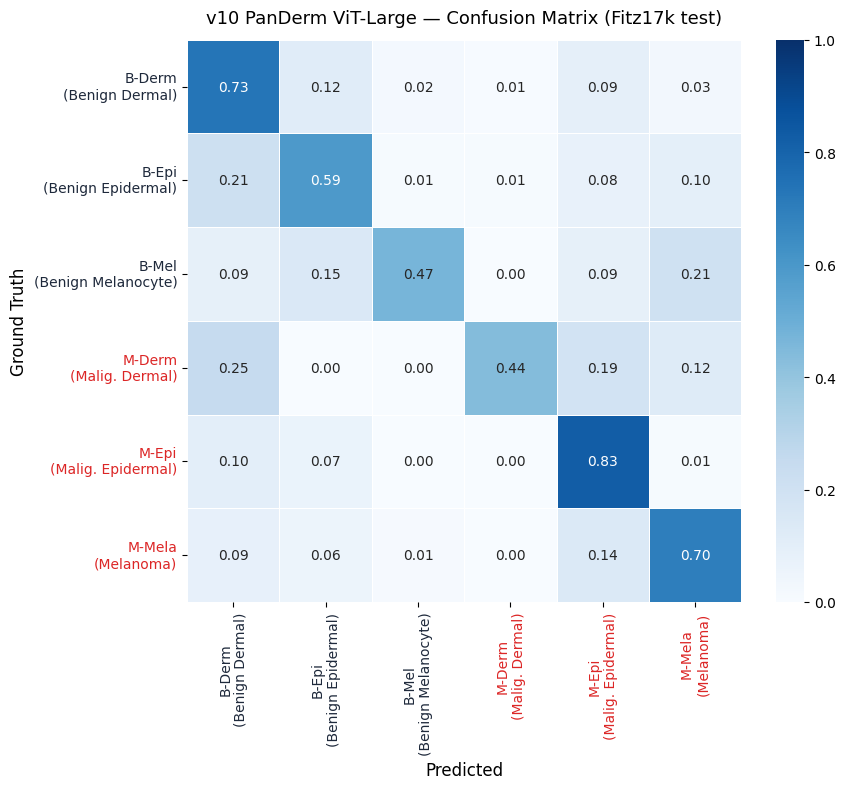


Malignant -> Benign misclassification:
  M-Derm -> B-Derm: 0.250
  M-Epi -> B-Derm: 0.098
  M-Epi -> B-Epi: 0.066
  M-Mela -> B-Derm: 0.086
  M-Mela -> B-Epi: 0.057
  M-Mela -> B-Mel: 0.014


In [4]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[CLASS_LABELS[c] for c in CLASS_NAMES],
    yticklabels=[CLASS_LABELS[c] for c in CLASS_NAMES],
    ax=ax, vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Ground Truth', fontsize=12)
ax.set_title('v10 PanDerm ViT-Large — Confusion Matrix (Fitz17k test)', fontsize=13, pad=12)

for i, cls in enumerate(CLASS_NAMES):
    color = '#dc2626' if cls in MALIGNANT else '#1e293b'
    ax.get_xticklabels()[i].set_color(color)
    ax.get_yticklabels()[i].set_color(color)

plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_confusion_matrix.png', dpi=150)
plt.show()

# Malignant -> Benign misclassification
print(f'\nMalignant -> Benign misclassification:')
for i, cls_true in enumerate(CLASS_NAMES):
    if cls_true not in MALIGNANT:
        continue
    for j, cls_pred in enumerate(CLASS_NAMES):
        if cls_pred in MALIGNANT:
            continue
        if cm[i, j] > 0.01:
            print(f'  {CLASS_SHORT[cls_true]} -> {CLASS_SHORT[cls_pred]}: {cm[i, j]:.3f}')

## 2. t-SNE (by class)

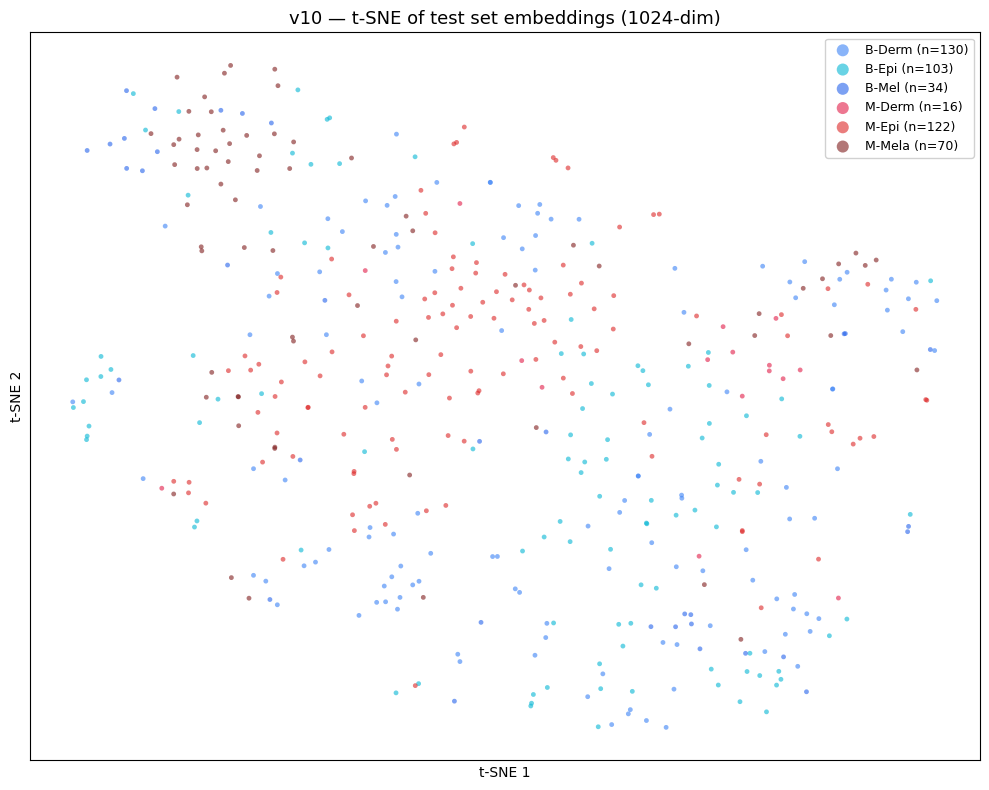

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embedding = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(CLASS_NAMES):
    mask = y_true == i
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=CLASS_COLORS[cls], label=f'{CLASS_SHORT[cls]} (n={mask.sum()})',
        s=12, alpha=0.6, edgecolors='none',
    )
ax.legend(fontsize=9, markerscale=2.5, loc='best', framealpha=0.9)
ax.set_title('v10 — t-SNE of test set embeddings (1024-dim)', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_tsne_class.png', dpi=150)
plt.show()

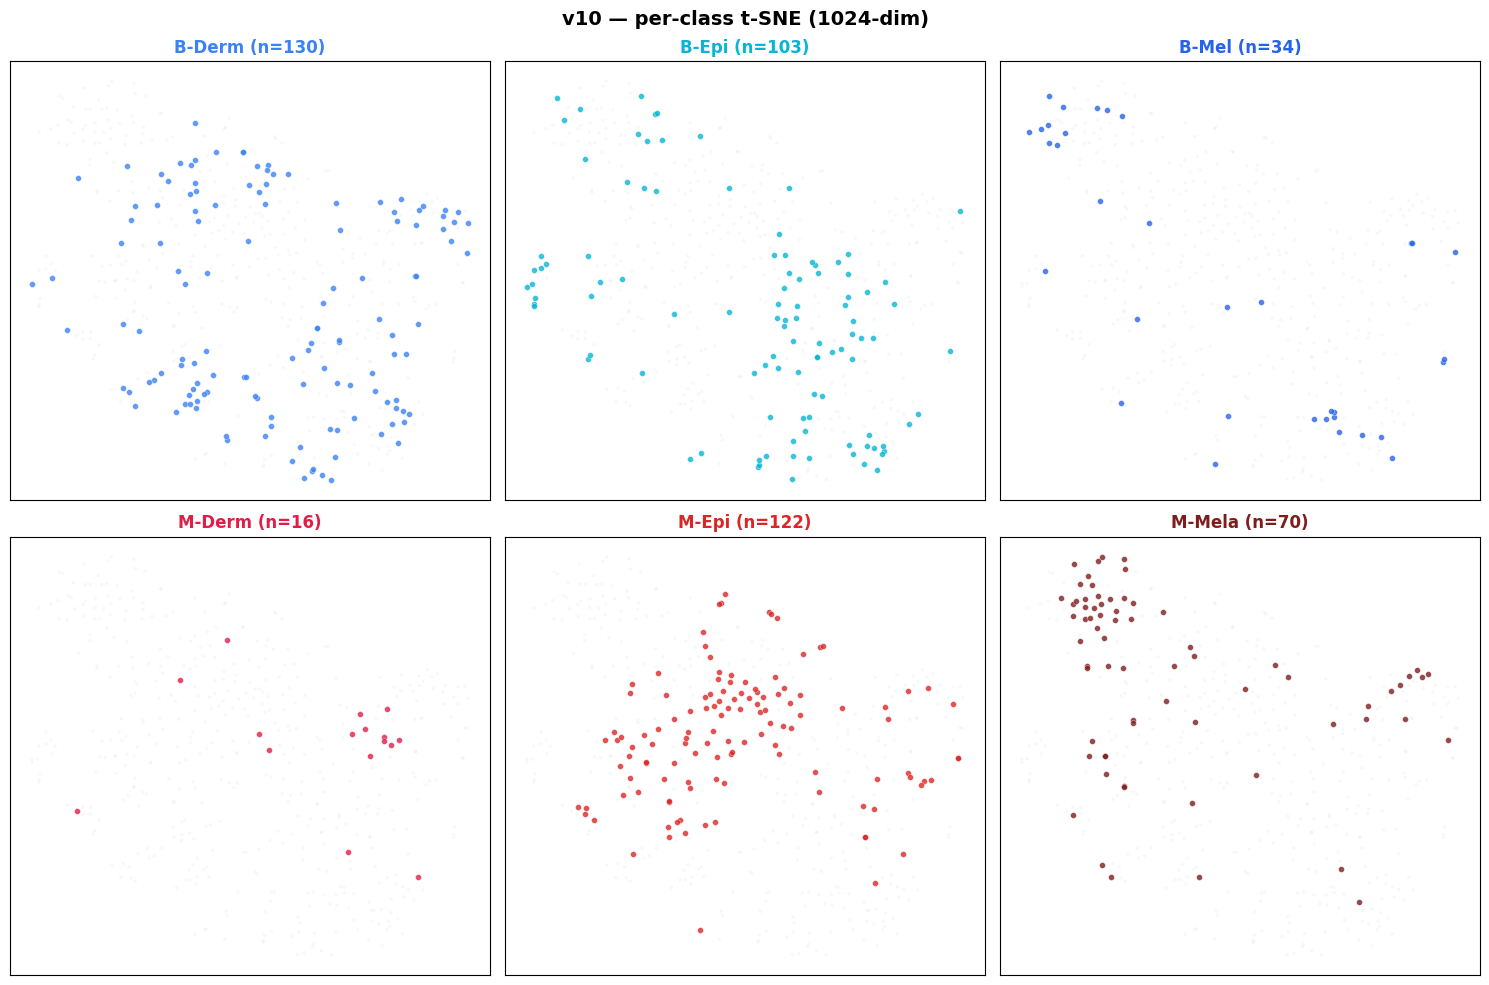

In [6]:
# Per-class t-SNE highlight
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    ax = axes[i]
    mask = y_true == i
    other = ~mask
    ax.scatter(embedding[other, 0], embedding[other, 1],
               c='#e2e8f0', s=6, alpha=0.3, edgecolors='none')
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=CLASS_COLORS[cls], s=18, alpha=0.8, edgecolors='white', linewidths=0.3)
    ax.set_title(f'{CLASS_SHORT[cls]} (n={mask.sum()})', fontsize=12, fontweight='bold', color=CLASS_COLORS[cls])
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('v10 — per-class t-SNE (1024-dim)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_tsne_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. t-SNE (class + argmax misclassification highlight)

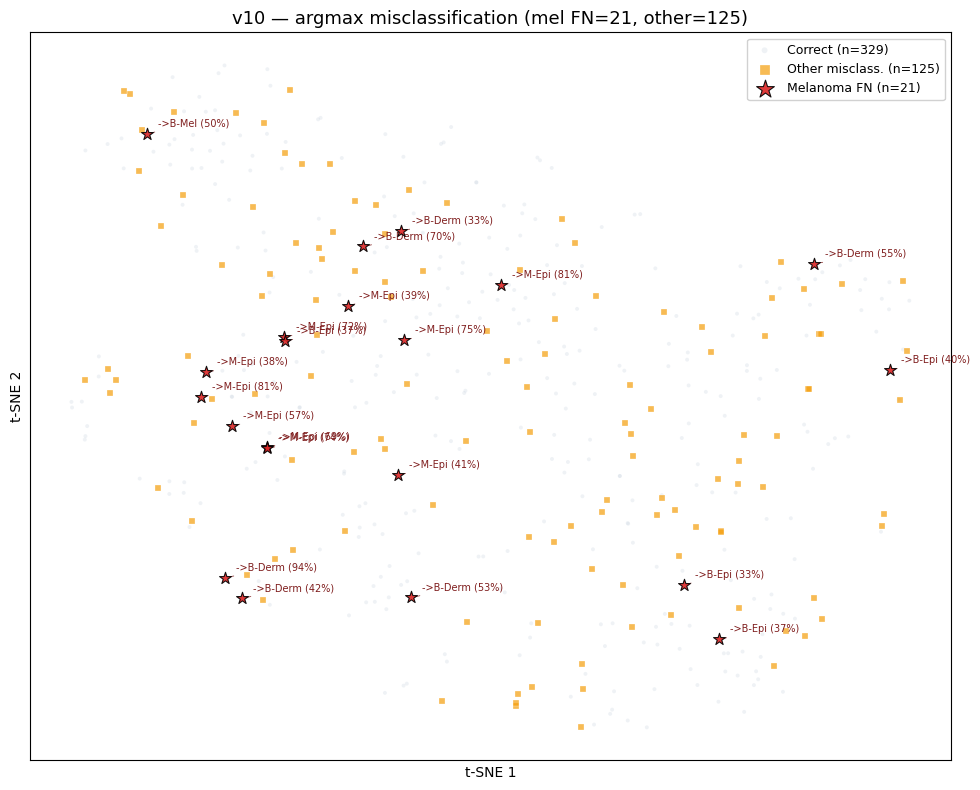

In [7]:
is_correct = y_pred == y_true
is_misclass = ~is_correct
is_mel_fn = (y_true == MEL_IDX) & is_misclass  # melanoma FN (critical)
is_other_misclass = is_misclass & ~is_mel_fn

fig, ax = plt.subplots(figsize=(10, 8))

# Correct: light gray
ax.scatter(
    embedding[is_correct, 0], embedding[is_correct, 1],
    c='#cbd5e1', s=8, alpha=0.3, edgecolors='none',
    label=f'Correct (n={is_correct.sum()})',
)

# Other misclassifications: orange square
ax.scatter(
    embedding[is_other_misclass, 0], embedding[is_other_misclass, 1],
    c='#f59e0b', s=25, alpha=0.7, edgecolors='white', linewidths=0.3,
    label=f'Other misclass. (n={is_other_misclass.sum()})', marker='s',
)

# Melanoma FN: red star
ax.scatter(
    embedding[is_mel_fn, 0], embedding[is_mel_fn, 1],
    c='#dc2626', s=80, alpha=0.9, edgecolors='black', linewidths=0.8,
    label=f'Melanoma FN (n={is_mel_fn.sum()})', marker='*', zorder=10,
)

# Melanoma FN annotations
for idx in np.where(is_mel_fn)[0]:
    pred_cls = CLASS_SHORT[CLASS_NAMES[y_pred[idx]]]
    conf = all_probs[idx, y_pred[idx]]
    ax.annotate(
        f'->{pred_cls} ({conf:.0%})',
        (embedding[idx, 0], embedding[idx, 1]),
        fontsize=7, color='#7f1d1d',
        textcoords='offset points', xytext=(8, 5),
        arrowprops=dict(arrowstyle='-', color='#7f1d1d', lw=0.5),
    )

ax.legend(fontsize=9, markerscale=1.5, loc='best', framealpha=0.9)
ax.set_title(f'v10 — argmax misclassification (mel FN={is_mel_fn.sum()}, other={is_other_misclass.sum()})', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_tsne_class_misclass.png', dpi=150)
plt.show()

## 4. t-SNE (malignant/benign binary)

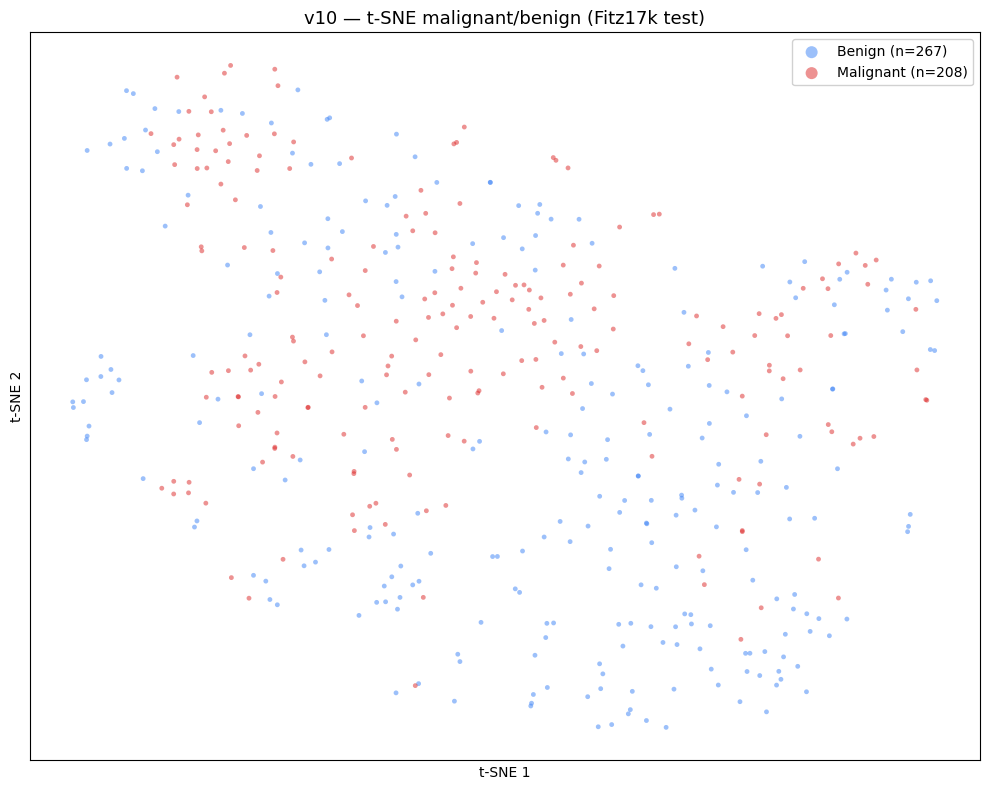

In [8]:
y_true_bin = np.isin(y_true, MALIGNANT_INDICES).astype(int)
n_mal = y_true_bin.sum()
n_ben = (1 - y_true_bin).sum()

fig, ax = plt.subplots(figsize=(10, 8))

# Benign: blue
ben_mask = y_true_bin == 0
ax.scatter(
    embedding[ben_mask, 0], embedding[ben_mask, 1],
    c='#3b82f6', s=12, alpha=0.5, edgecolors='none',
    label=f'Benign (n={n_ben})',
)

# Malignant: red
mal_mask = y_true_bin == 1
ax.scatter(
    embedding[mal_mask, 0], embedding[mal_mask, 1],
    c='#dc2626', s=12, alpha=0.5, edgecolors='none',
    label=f'Malignant (n={n_mal})',
)

ax.legend(fontsize=10, markerscale=2.5, loc='best', framealpha=0.9)
ax.set_title('v10 — t-SNE malignant/benign (Fitz17k test)', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_tsne_binary.png', dpi=150)
plt.show()

## 5. t-SNE (binary threshold-based misclassification)

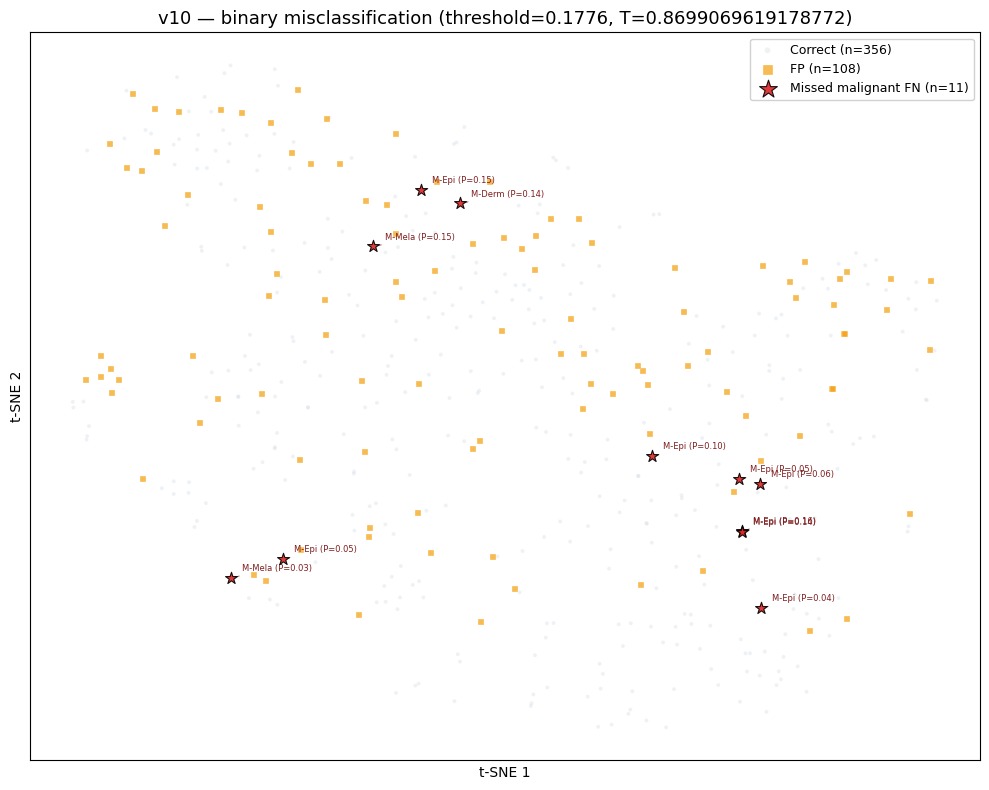

In [9]:
# Binary classification with TS-calibrated probs
p_mal = all_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)
y_pred_bin = (p_mal >= BINARY_THRESHOLD).astype(int)

is_correct_bin = y_pred_bin == y_true_bin
is_fn = (y_true_bin == 1) & (y_pred_bin == 0)  # missed malignant
is_fp = (y_true_bin == 0) & (y_pred_bin == 1)  # benign classified as malignant

fig, ax = plt.subplots(figsize=(10, 8))

# Correct: light gray
ax.scatter(
    embedding[is_correct_bin, 0], embedding[is_correct_bin, 1],
    c='#cbd5e1', s=8, alpha=0.3, edgecolors='none',
    label=f'Correct (n={is_correct_bin.sum()})',
)

# FP: orange square
ax.scatter(
    embedding[is_fp, 0], embedding[is_fp, 1],
    c='#f59e0b', s=25, alpha=0.7, edgecolors='white', linewidths=0.3,
    label=f'FP (n={is_fp.sum()})', marker='s',
)

# FN (missed malignant): red star
ax.scatter(
    embedding[is_fn, 0], embedding[is_fn, 1],
    c='#dc2626', s=80, alpha=0.9, edgecolors='black', linewidths=0.8,
    label=f'Missed malignant FN (n={is_fn.sum()})', marker='*', zorder=10,
)

# FN annotations (true class + P(mal))
for idx in np.where(is_fn)[0]:
    true_cls = CLASS_SHORT[CLASS_NAMES[y_true[idx]]]
    ax.annotate(
        f'{true_cls} (P={p_mal[idx]:.2f})',
        (embedding[idx, 0], embedding[idx, 1]),
        fontsize=6, color='#7f1d1d',
        textcoords='offset points', xytext=(8, 5),
        arrowprops=dict(arrowstyle='-', color='#7f1d1d', lw=0.5),
    )

ax.legend(fontsize=9, markerscale=1.5, loc='best', framealpha=0.9)
ax.set_title(f'v10 — binary misclassification (threshold={BINARY_THRESHOLD:.4f}, T={T})', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
fig.savefig(OUT_DIR / 'v10_tsne_binary_misclass.png', dpi=150)
plt.show()

## Summary

In [10]:
print(f'=== v10 t-SNE Summary ===')
print(f'  test N: {N}')
print(f'  argmax accuracy: {(y_pred == y_true).mean():.4f}')
print(f'  argmax misclass.: {is_misclass.sum()} ({is_misclass.mean():.1%})')
print(f'    of which melanoma FN: {is_mel_fn.sum()}')
print()
print(f'  Binary (T={T}, threshold={BINARY_THRESHOLD:.4f}):')
print(f'    FN (missed malignant): {is_fn.sum()} / {n_mal} ({is_fn.sum()/max(n_mal,1):.1%})')
print(f'    FP: {is_fp.sum()} / {n_ben}')
print()
print(f'  Melanoma FN (argmax) predicted as:')
for idx in np.where(is_mel_fn)[0]:
    pred_cls = CLASS_SHORT[CLASS_NAMES[y_pred[idx]]]
    conf = all_probs[idx, y_pred[idx]]
    print(f'    -> {pred_cls} (conf={conf:.3f})')
print()
print(f'  Binary FN breakdown (by true class):')
for idx in np.where(is_fn)[0]:
    true_cls = CLASS_SHORT[CLASS_NAMES[y_true[idx]]]
    print(f'    {true_cls} (P(mal)={p_mal[idx]:.3f})')
print()
print(f'Output: {OUT_DIR}/')
for f in sorted(OUT_DIR.glob('v10_*')):
    print(f'  {f.name}')

=== v10 t-SNE Summary ===
  test N: 475
  argmax accuracy: 0.6926
  argmax misclass.: 146 (30.7%)
    of which melanoma FN: 21

  Binary (T=0.8699069619178772, threshold=0.1776):
    FN (missed malignant): 11 / 208 (5.3%)
    FP: 108 / 267

  Melanoma FN (argmax) predicted as:
    -> M-Epi (conf=0.566)
    -> M-Epi (conf=0.687)
    -> M-Epi (conf=0.748)
    -> B-Derm (conf=0.554)
    -> B-Epi (conf=0.325)
    -> B-Derm (conf=0.333)
    -> B-Derm (conf=0.702)
    -> M-Epi (conf=0.722)
    -> B-Derm (conf=0.943)
    -> B-Epi (conf=0.367)
    -> M-Epi (conf=0.379)
    -> M-Epi (conf=0.808)
    -> B-Epi (conf=0.403)
    -> M-Epi (conf=0.412)
    -> B-Derm (conf=0.416)
    -> B-Derm (conf=0.534)
    -> M-Epi (conf=0.741)
    -> M-Epi (conf=0.811)
    -> B-Epi (conf=0.371)
    -> B-Mel (conf=0.498)
    -> M-Epi (conf=0.394)

  Binary FN breakdown (by true class):
    M-Epi (P(mal)=0.047)
    M-Epi (P(mal)=0.035)
    M-Epi (P(mal)=0.158)
    M-Epi (P(mal)=0.148)
    M-Mela (P(mal)=0.150)
    

## Export to PDF

In [11]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

PAGES = [
    ('v10_confusion_matrix.png',     'Confusion Matrix (6-class, normalized)'),
    ('v10_tsne_class.png',           't-SNE — class distribution'),
    ('v10_tsne_perclass.png',        't-SNE — per-class highlight'),
    ('v10_tsne_class_misclass.png',  't-SNE — argmax misclassification (melanoma FN highlighted)'),
    ('v10_tsne_binary.png',          't-SNE — malignant / benign binary'),
    ('v10_tsne_binary_misclass.png', 't-SNE — binary threshold misclassification (FN / FP)'),
]

pdf_path = OUT_DIR / 'v10_tsne_report.pdf'
with PdfPages(pdf_path) as pdf:
    # Title page
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('off')
    ax.text(0.5, 0.55, 'DermLens v10 — PanDerm ViT-Large / Fitzpatrick17k test',
            ha='center', va='center', fontsize=22, fontweight='bold')
    ax.text(0.5, 0.42, 'Confusion Matrix + t-SNE Misclassification Analysis',
            ha='center', va='center', fontsize=14, color='#475569')
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    for fname, subtitle in PAGES:
        img = mpimg.imread(str(OUT_DIR / fname))
        fig, ax = plt.subplots(figsize=(11.69, 8.27))
        fig.text(0.5, 0.96, subtitle, ha='center', va='top',
                 fontsize=11, color='#475569', style='italic')
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.94])
        pdf.savefig(fig, dpi=150)
        plt.close(fig)

print(f'PDF saved: {pdf_path} ({len(PAGES)+1} pages)')

PDF saved: ../results/tsne/v10_tsne_report.pdf (7 pages)
